# Experimento 9 — PubMedBERT-large (encoder grande)

**Punto de partida:** Exp5 = PubMedBERT-*base* + typed markers + neg_ratio 1:1 + class weights → **Macro F1 0.8507** (mejor actual).

**Cambio (único de diseño):** subir el encoder de *base* (110M) a **`microsoft/BiomedNLP-BiomedBERT-large-uncased-abstract`**
(340M), antes llamado "PubMedBERT large". Todo lo demás (typed markers, neg_ratio 1:1, class weights, lr, epochs) igual.

**Hipótesis:** Sänger & Leser (BMC Bioinformatics 2025) reportan que los encoders biomédicos *large* baten a los *base*
en RE. Tus swaps previos fueron a versiones *base* (BioLinkBERT-base 0.7576, XLM-R-base 0.7180) → no medían tamaño.

**Cambio forzado (no de diseño):** por memoria de GPU, `batch_size` baja de 16 → **8**. Si hay OOM: `batch=4` o `max_length=192`.

> **Este notebook es autónomo:** genera él mismo los datos con typed markers a partir de tus datos ORIGINALES
> (`eng_train.txt`, `eng_dev.txt`, `rel2id.json` del dataset de Kaggle). No necesita ficheros del Exp5.
> La lógica de preparación es **idéntica** a la del Exp5 para que la comparación sea limpia.

**Cómo usarlo:** sube el notebook a Kaggle, activa GPU, asegúrate de tener adjunto tu dataset con los datos
originales, y dale a **Run All**. La celda final te dice si mejora o no sobre 0.8507.


## 1. Setup y parche de OpenNRE (AdamW)

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("lucaespernjj/9-outputs")

print("Path to dataset files:", path)

Mounting files to /kaggle/input/datasets/lucaespernjj/9-outputs...


In [19]:
# Solo la primera vez
!pip install git+https://github.com/thunlp/OpenNRE.git -q
!pip install torch transformers nltk pandas scikit-learn matplotlib seaborn -q

  Preparing metadata (setup.py) ... done


In [20]:
import json, time, os, importlib, logging, random
from pathlib import Path
from collections import Counter
import numpy as np, torch
logging.getLogger("transformers").setLevel(logging.ERROR)
os.environ["TRANSFORMERS_VERBOSITY"] = "error"
import opennre

# parche AdamW (idéntico a tus notebooks previos)
import opennre.framework.sentence_re as sre
p = Path(sre.__file__); t = p.read_text(encoding="utf-8")
t = t.replace("from transformers import AdamW", "from torch.optim import AdamW")
t = t.replace("self.optimizer = AdamW(grouped_params, correct_bias=False)", "self.optimizer = AdamW(grouped_params)")
p.write_text(t, encoding="utf-8"); importlib.reload(sre); opennre.framework.SentenceRE = sre.SentenceRE
print("PyTorch:", torch.__version__, "| CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0),
          f"| VRAM {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

def fix_encoder_for_large(encoder):
    """OpenNRE hardcodea hidden_size=768 (modelo base). Para el modelo LARGE (hidden=1024)
    hay que reconstruir la capa lineal al tamaño real, o falla con
    'mat1 and mat2 shapes cannot be multiplied (Nx2048 and 1536x1536)'."""
    h = encoder.bert.config.hidden_size          # 1024 en el large, 768 en el base
    expected = h * 2                             # se concatenan head+tail
    if getattr(encoder, "hidden_size", None) != expected:
        encoder.hidden_size = expected
        encoder.linear = torch.nn.Linear(expected, expected)
        print(f"[fix] encoder ajustado a hidden_size={h} -> linear {expected}x{expected}")
    else:
        print(f"[fix] no hace falta ajuste (hidden_size={h})")
    return encoder


PyTorch: 2.10.0+cu128 | CUDA: True
GPU: Tesla T4 | VRAM 15.6 GB


## 2. Configuración — ÚNICO cambio de diseño: `MODEL_NAME` a la versión *large*

In [21]:
# ====== CONFIG EXP9 ======
MODEL_NAME = "microsoft/BiomedNLP-BiomedBERT-large-uncased-abstract"   # <<< antes: ...-base-...-fulltext
EXPERIMENT_NAME = "pubmedbert_LARGE_typed_neg1_classweights"

MAX_LENGTH   = 256
BATCH_SIZE   = 8      # <<< bajado de 16 por memoria (cambio forzado, no de diseño)
LEARNING_RATE= 2e-5   # si la loss oscila/no baja con el modelo grande, prueba 1e-5
EPOCHS       = 15
WARMUP_STEPS = 300
SEED         = 42
TARGET_NEG_RATIO = 1.0

# --- DATOS ORIGINALES (los que SÍ tienes) ---
DATA_DIR   = Path("/kaggle/input/datasets/lucaespernjj/bionner-data")   # <<< ajusta si tu dataset está en otra ruta
ORIG_TRAIN = DATA_DIR / "eng_train.txt"
ORIG_DEV   = DATA_DIR / "eng_dev.txt"
REL2ID_PATH= DATA_DIR / "rel2id.json"

# --- SALIDAS (se generan aquí) ---
OUTPUT_DIR = Path("/kaggle/working/outputs"); OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
TYPED_TRAIN = OUTPUT_DIR / "eng_train_typed_neg1.txt"   # se genera en la celda 3
TYPED_DEV   = OUTPUT_DIR / "eng_dev_typed.txt"          # se genera en la celda 3
CKPT_PATH   = OUTPUT_DIR / f"eng_{EXPERIMENT_NAME}.pth.tar"

assert ORIG_TRAIN.exists() and ORIG_DEV.exists() and REL2ID_PATH.exists(), (
    f"No encuentro los datos originales en {DATA_DIR}. Ajusta DATA_DIR a la ruta de tu dataset de Kaggle.")

rel2id = json.load(open(REL2ID_PATH)); id2rel = {v:k for k,v in rel2id.items()}
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
print("clases:", len(rel2id), "| modelo:", MODEL_NAME)

clases: 15 | modelo: microsoft/BiomedNLP-BiomedBERT-large-uncased-abstract


## 3. Preparar datos: typed markers + neg_ratio 1:1

Estas dos funciones son **copia exacta del Exp5**. Insertan los marcadores de tipo en el texto
(`[HEAD-ANATOMY] ... [/HEAD-ANATOMY]`) y equilibran los negativos a 1:1 en train (el dev NO se toca).

In [22]:
def _build_typed_text(text, h_start, h_end, t_start, t_end, h_type, t_type):
    """Inserta typed entity markers y recalcula posiciones. IDÉNTICA al Exp2/Exp5."""
    h_open=f"[HEAD-{h_type}] "; h_close=f" [/HEAD-{h_type}]"
    t_open=f"[TAIL-{t_type}] "; t_close=f" [/TAIL-{t_type}]"
    events=[(h_start,0,"h_open",h_open),(h_end,1,"h_close",h_close),
            (t_start,0,"t_open",t_open),(t_end,1,"t_close",t_close)]
    events.sort(key=lambda x:(x[0],x[1]))
    parts=[]; prev=0; nhs=nhe=nts=nte=0
    for pos,_,et,mk in events:
        parts.append(text[prev:pos])
        if et=="h_open": parts.append(mk); nhs=sum(len(x) for x in parts)
        elif et=="h_close": nhe=sum(len(x) for x in parts); parts.append(mk)
        elif et=="t_open": parts.append(mk); nts=sum(len(x) for x in parts)
        elif et=="t_close": nte=sum(len(x) for x in parts); parts.append(mk)
        prev=pos
    parts.append(text[prev:])
    return "".join(parts), [nhs,nhe], [nts,nte]

def transform_and_subsample(input_path, output_path, target_neg_ratio=None, seed=42):
    """Subsamplea negativos (si target_neg_ratio) y aplica typed markers. IDÉNTICA al Exp5."""
    rng=random.Random(seed); pos=[]; neg=[]
    for line in open(input_path, encoding="utf-8"):
        line=line.strip()
        if not line: continue
        inst=json.loads(line)
        (neg if inst["relation"]=="no_relation" else pos).append(inst)
    if target_neg_ratio is not None:
        n_keep=min(int(len(pos)*target_neg_ratio), len(neg)); neg=rng.sample(neg, n_keep)
    allx=pos+neg; rng.shuffle(allx); ok=err=0
    with open(output_path,"w",encoding="utf-8") as f:
        for inst in allx:
            try:
                hs,he=inst["h"]["pos"]; ts,te=inst["t"]["pos"]
                nt,nh,ntp=_build_typed_text(inst["text"],hs,he,ts,te,inst["head_type"],inst["tail_type"])
                ni=dict(inst); ni["text"]=nt
                ni["h"]=dict(inst["h"]); ni["h"]["pos"]=nh
                ni["t"]=dict(inst["t"]); ni["t"]["pos"]=ntp
                f.write(json.dumps(ni,ensure_ascii=False)+"\n"); ok+=1
            except Exception:
                f.write(json.dumps(inst,ensure_ascii=False)+"\n"); err+=1
    return len(pos), len(neg), ok, err

print("Generando train (typed markers + neg_ratio 1:1)...")
a,b,ok,err = transform_and_subsample(ORIG_TRAIN, TYPED_TRAIN, TARGET_NEG_RATIO, seed=SEED)
print(f"  train: {a} pos + {b} neg = {a+b}  ({ok} ok, {err} err) -> {TYPED_TRAIN.name}")
print("Generando dev (typed markers, SIN subsamplear)...")
c,d,ok2,err2 = transform_and_subsample(ORIG_DEV, TYPED_DEV, None, seed=SEED)
print(f"  dev: {c} pos + {d} neg = {c+d}  ({ok2} ok, {err2} err) -> {TYPED_DEV.name}")

Generando train (typed markers + neg_ratio 1:1)...
  train: 3193 pos + 3193 neg = 6386  (6386 ok, 0 err) -> eng_train_typed_neg1.txt
Generando dev (typed markers, SIN subsamplear)...
  dev: 2967 pos + 0 neg = 2967  (2967 ok, 0 err) -> eng_dev_typed.txt


## 4. Class weights (frecuencia inversa) — idéntico al Exp5

In [23]:
train_insts=[json.loads(l) for l in open(TYPED_TRAIN,encoding="utf-8") if l.strip()]
counts=Counter(i["relation"] for i in train_insts)
n_total,n_classes=len(train_insts),len(rel2id)
CLASS_WEIGHTS=torch.zeros(n_classes)
for rel,rid in rel2id.items():
    c=counts.get(rel,0); CLASS_WEIGHTS[rid]=n_total/(n_classes*c) if c else 1.0
print("train:",n_total,"instancias")
for rel,rid in sorted(rel2id.items(),key=lambda x:x[1]):
    print(f"  {rel:<22} count={counts.get(rel,0):>5}  w={CLASS_WEIGHTS[rid]:.3f}")

train: 6386 instancias
  ABBREVIATION           count=   97  w=4.389
  ALTERNATIVE_NAME       count=   95  w=4.481
  SUBCLASS_OF            count=  743  w=0.573
  PART_OF                count=  204  w=2.087
  TREATED_USING          count=  101  w=4.215
  ORIGINS_FROM           count=  120  w=3.548
  TO_DETECT_OR_STUDY     count=  164  w=2.596
  AFFECTS                count=  362  w=1.176
  HAS_CAUSE              count=  579  w=0.735
  APPLIED_TO             count=   43  w=9.901
  USED_IN                count=   89  w=4.784
  ASSOCIATED_WITH        count=  325  w=1.310
  PHYSIOLOGY_OF          count=  150  w=2.838
  FINDING_OF             count=  121  w=3.518
  no_relation            count= 3193  w=0.133


## 5. Entrenamiento (large + class weights)

In [16]:
torch.manual_seed(SEED); np.random.seed(SEED)
encoder = opennre.encoder.BERTEntityEncoder(max_length=MAX_LENGTH, pretrain_path=MODEL_NAME)
encoder = fix_encoder_for_large(encoder)          # <<< ARREGLO para modelo large
model = opennre.model.SoftmaxNN(encoder, len(rel2id), rel2id)
fw = opennre.framework.SentenceRE(
    model=model, train_path=str(TYPED_TRAIN), val_path=str(TYPED_DEV), test_path=str(TYPED_DEV),
    ckpt=str(CKPT_PATH), batch_size=BATCH_SIZE, max_epoch=EPOCHS,
    lr=LEARNING_RATE, opt="adamw", warmup_step=WARMUP_STEPS)
w = CLASS_WEIGHTS.cuda() if torch.cuda.is_available() else CLASS_WEIGHTS
fw.criterion = torch.nn.CrossEntropyLoss(weight=w)   # único añadido vs default, igual que Exp5
print("Loss:", fw.criterion)
t0=time.time(); fw.train_model(metric="micro_f1")
print(f"\nEntrenamiento: {(time.time()-t0)/60:.1f} min | ckpt: {CKPT_PATH.name}")

2026-07-07 15:56:19,180 - root - INFO - Loading BERT pre-trained checkpoint.
2026-07-07 15:56:19,278 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/microsoft/BiomedNLP-BiomedBERT-large-uncased-abstract/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-07-07 15:56:19,285 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/microsoft/BiomedNLP-BiomedBERT-large-uncased-abstract/f18ff5ec008285849e7c467b2618262b0def6238/config.json "HTTP/1.1 200 OK"
2026-07-07 15:56:19,304 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/microsoft/BiomedNLP-BiomedBERT-large-uncased-abstract/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-07-07 15:56:19,311 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/microsoft/BiomedNLP-BiomedBERT-large-uncased-abstract/f18ff5ec008285849e7c467b2618262b0def6238/config.json "HTTP/1.1 200 OK"
2026-07-07 15:56:19,347 - httpx - INFO - HTTP Request: HEAD https

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

2026-07-07 15:56:21,312 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/microsoft/BiomedNLP-BiomedBERT-large-uncased-abstract/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
2026-07-07 15:56:21,329 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/microsoft/BiomedNLP-BiomedBERT-large-uncased-abstract/f18ff5ec008285849e7c467b2618262b0def6238/tokenizer_config.json "HTTP/1.1 200 OK"
2026-07-07 15:56:21,389 - httpx - INFO - HTTP Request: GET https://huggingface.co/api/models/microsoft/BiomedNLP-BiomedBERT-large-uncased-abstract/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
2026-07-07 15:56:21,417 - httpx - INFO - HTTP Request: GET https://huggingface.co/api/models/microsoft/BiomedNLP-BiomedBERT-large-uncased-abstract/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"


[fix] encoder ajustado a hidden_size=1024 -> linear 2048x2048


2026-07-07 15:56:21,937 - root - INFO - Loaded sentence RE dataset /kaggle/working/outputs/eng_train_typed_neg1.txt with 6386 lines and 15 relations.
2026-07-07 15:56:22,099 - root - INFO - Loaded sentence RE dataset /kaggle/working/outputs/eng_dev_typed.txt with 2967 lines and 15 relations.
2026-07-07 15:56:22,261 - root - INFO - Loaded sentence RE dataset /kaggle/working/outputs/eng_dev_typed.txt with 2967 lines and 15 relations.
2026-07-07 15:56:22,598 - root - INFO - === Epoch 0 train ===


Loss: CrossEntropyLoss()


100%|██████████| 799/799 [13:17<00:00,  1.00it/s, acc=0.587, loss=1.38]
2026-07-07 16:09:39,699 - root - INFO - === Epoch 0 val ===
100%|██████████| 371/371 [02:08<00:00,  2.89it/s, acc=0.77] 
2026-07-07 16:11:48,032 - root - INFO - Evaluation result: {'acc': 0.7701381867205932, 'micro_p': 0.8363836017569546, 'micro_r': 0.7701381867205932, 'micro_f1': 0.8018950693104053}.
2026-07-07 16:11:48,033 - root - INFO - Metric micro_f1 current / best: 0.8018950693104053 / 0
2026-07-07 16:11:48,034 - root - INFO - Best ckpt and saved.
2026-07-07 16:11:49,537 - root - INFO - === Epoch 1 train ===
100%|██████████| 799/799 [13:18<00:00,  1.00it/s, acc=0.838, loss=0.434]
2026-07-07 16:25:08,324 - root - INFO - === Epoch 1 val ===
100%|██████████| 371/371 [02:08<00:00,  2.88it/s, acc=0.834]
2026-07-07 16:27:17,053 - root - INFO - Evaluation result: {'acc': 0.8341759352881699, 'micro_p': 0.8602711157455682, 'micro_r': 0.8341759352881699, 'micro_f1': 0.8470225872689938}.
2026-07-07 16:27:17,054 - root 


Entrenamiento: 232.0 min | ckpt: eng_pubmedbert_LARGE_typed_neg1_classweights.pth.tar


## 6. Evaluación — Macro F1 (métrica oficial) sobre dev

In [24]:
# Si no re-entrenaste en ESTA sesion, CKPT_PATH (bajo /kaggle/working/outputs) no existe --
# usa el checkpoint ya entrenado que tienes guardado como dataset de Kaggle.
_CKPT_FALLBACK = Path("/kaggle/input/datasets/lucaespernjj/9-outputs/eng_pubmedbert_LARGE_typed_neg1_classweights.pth.tar")
if not CKPT_PATH.exists() and _CKPT_FALLBACK.exists():
    CKPT_PATH = _CKPT_FALLBACK
    print(f"[info] no hay checkpoint de esta sesion -> uso el ya entrenado: {CKPT_PATH}")
else:
    print(f"[info] usando CKPT_PATH: {CKPT_PATH}")

[info] no hay checkpoint de esta sesion -> uso el ya entrenado: /kaggle/input/datasets/lucaespernjj/9-outputs/eng_pubmedbert_LARGE_typed_neg1_classweights.pth.tar


In [25]:
enc2 = opennre.encoder.BERTEntityEncoder(max_length=MAX_LENGTH, pretrain_path=MODEL_NAME)
enc2 = fix_encoder_for_large(enc2)                # <<< mismo ARREGLO al recargar
m2 = opennre.model.SoftmaxNN(enc2, len(rel2id), rel2id)
m2.load_state_dict(torch.load(str(CKPT_PATH), map_location="cpu")["state_dict"])
if torch.cuda.is_available(): m2=m2.cuda()
m2.eval()

dev=[json.loads(l) for l in open(TYPED_DEV,encoding="utf-8") if l.strip()]
gold,pred=[],[]
with torch.no_grad():
    for inst in dev:
        item={"text": inst.get("text") or " ".join(inst.get("token",[])),
              "h": inst["h"], "t": inst["t"]}
        rel,_ = m2.infer(item)         # OpenNRE SoftmaxNN.infer -> (relacion, score)
        gold.append(inst["relation"]); pred.append(rel)

rels=[r for r in rel2id if r!="no_relation"]
gc,pc=Counter(gold),Counter(pred); tp=Counter(g for g,p in zip(gold,pred) if g==p)
print(f"{'Relacion':<22}{'P':>8}{'R':>8}{'F1':>8}{'sup':>6}")
f1s=[]
for r in rels:
    p_=tp[r]/pc[r] if pc[r] else 0; rc=tp[r]/gc[r] if gc[r] else 0
    f1=2*p_*rc/(p_+rc) if (p_+rc) else 0
    if gc[r]>0: f1s.append(f1); print(f"{r:<22}{p_:>8.3f}{rc:>8.3f}{f1:>8.3f}{gc[r]:>6}")
macro=sum(f1s)/len(f1s); acc=sum(1 for g,p in zip(gold,pred) if g==p)/len(gold)
print("-"*52); print(f"Accuracy: {acc:.4f} | MACRO F1: {macro:.4f}")

2026-07-13 10:49:30,558 - root - INFO - Loading BERT pre-trained checkpoint.
2026-07-13 10:49:30,674 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/microsoft/BiomedNLP-BiomedBERT-large-uncased-abstract/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-07-13 10:49:30,691 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/microsoft/BiomedNLP-BiomedBERT-large-uncased-abstract/f18ff5ec008285849e7c467b2618262b0def6238/config.json "HTTP/1.1 200 OK"
2026-07-13 10:49:30,739 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/microsoft/BiomedNLP-BiomedBERT-large-uncased-abstract/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-07-13 10:49:30,756 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/microsoft/BiomedNLP-BiomedBERT-large-uncased-abstract/f18ff5ec008285849e7c467b2618262b0def6238/config.json "HTTP/1.1 200 OK"
2026-07-13 10:49:30,808 - httpx - INFO - HTTP Request: HEAD https

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

2026-07-13 10:49:32,745 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/microsoft/BiomedNLP-BiomedBERT-large-uncased-abstract/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
2026-07-13 10:49:32,765 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/microsoft/BiomedNLP-BiomedBERT-large-uncased-abstract/f18ff5ec008285849e7c467b2618262b0def6238/tokenizer_config.json "HTTP/1.1 200 OK"
2026-07-13 10:49:32,856 - httpx - INFO - HTTP Request: GET https://huggingface.co/api/models/microsoft/BiomedNLP-BiomedBERT-large-uncased-abstract/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
2026-07-13 10:49:32,908 - httpx - INFO - HTTP Request: GET https://huggingface.co/api/models/microsoft/BiomedNLP-BiomedBERT-large-uncased-abstract/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"


[fix] encoder ajustado a hidden_size=1024 -> linear 2048x2048
Relacion                     P       R      F1   sup
ABBREVIATION             0.930   0.892   0.910    74
ALTERNATIVE_NAME         0.803   0.500   0.616    98
SUBCLASS_OF              0.889   0.878   0.884   757
PART_OF                  0.860   0.815   0.836   248
TREATED_USING            1.000   0.943   0.971    88
ORIGINS_FROM             0.812   0.987   0.891    79
TO_DETECT_OR_STUDY       0.908   0.767   0.832   116
AFFECTS                  1.000   0.926   0.962   393
HAS_CAUSE                0.923   0.858   0.889   487
APPLIED_TO               0.541   0.611   0.574    54
USED_IN                  0.762   0.772   0.767    79
ASSOCIATED_WITH          0.860   0.948   0.902   233
PHYSIOLOGY_OF            1.000   0.994   0.997   178
FINDING_OF               0.879   0.964   0.920    83
----------------------------------------------------
Accuracy: 0.8716 | MACRO F1: 0.8537


## 6b. Validación en modo ciego (blind) — mismo checkpoint

La sección 6 evalúa `m2`/`enc2` sobre `TYPED_DEV`, que solo contiene los pares positivos gold (+ typed markers) —
el mismo "modo etiquetado" que el README oficial de `nerel-ds/NEREL-BIO` retractó (ver notebook
`0-validacion-blind-oficial.ipynb`). Esta sección reutiliza el mismo `m2`/`enc2` ya cargados (**sin recargar
el checkpoint**) y evalúa en modo ciego real: **todos** los pares candidatos del dev (`eng_dev_blind.txt`,
generado con `prepare_data.py eng-dev-ent.tsv texts/ -o eng_dev_blind.txt`), pasados por el mismo pipeline de
typed markers (`_build_typed_text`, sección 3), y comparados contra el TSV gold real (`eng-dev-rel.tsv`).

In [26]:
# ====== Validacion en modo ciego (blind): reutiliza m2/enc2 ya cargados, NO recarga el checkpoint ======
BLIND_DEV_PATH = DATA_DIR / "eng_dev_blind.txt"
BLIND_GOLD_TSV = DATA_DIR / "eng-dev-rel.tsv"
BLIND_PRED_PATH = OUTPUT_DIR / f"eng_pred_blind_{EXPERIMENT_NAME}.tsv"
BLIND_RESULTS_PATH = OUTPUT_DIR / f"results_blind_{EXPERIMENT_NAME}.json"

for p in [BLIND_DEV_PATH, BLIND_GOLD_TSV]:
    print(f"{'OK ' if p.exists() else 'FALTA '} {p}")

OK  /kaggle/input/datasets/lucaespernjj/bionner-data/eng_dev_blind.txt
OK  /kaggle/input/datasets/lucaespernjj/bionner-data/eng-dev-rel.tsv


In [27]:
import pandas as pd

blind_raw = [json.loads(l) for l in open(BLIND_DEV_PATH, encoding="utf-8") if l.strip()]
gold_df_blind = pd.read_csv(BLIND_GOLD_TSV, sep="\t")
print(f"candidatos blind: {len(blind_raw)} | docs: {len(set(i['doc_id'] for i in blind_raw))} | gold real: {len(gold_df_blind)}")

blind_typed = []
for inst in blind_raw:
    hs, he = inst["h"]["pos"]; ts, te = inst["t"]["pos"]
    nt, nh, ntp = _build_typed_text(inst["text"], hs, he, ts, te, inst["head_type"], inst["tail_type"])
    ni = dict(inst); ni["text"] = nt
    ni["h"] = dict(inst["h"]); ni["h"]["pos"] = nh
    ni["t"] = dict(inst["t"]); ni["t"]["pos"] = ntp
    blind_typed.append(ni)
print(f"typed markers aplicados a {len(blind_typed)} candidatos (misma funcion _build_typed_text de la seccion 3)")

candidatos blind: 282364 | docs: 50 | gold real: 2891
typed markers aplicados a 282364 candidatos (misma funcion _build_typed_text de la seccion 3)


In [28]:
N_GPUS = torch.cuda.device_count()
# En inferencia (torch.no_grad(), sin backward ni estados de Adam) el modelo aguanta
# batches mucho mayores que en entrenamiento (que uso batch_size=8 por memoria del large).
# Si ves OOM, baja a 16; si sobra VRAM, prueba 48-64.
BLIND_BATCH_SIZE = 32 * max(1, N_GPUS)
infer_model = torch.nn.DataParallel(m2) if N_GPUS > 1 else m2
print(f"GPUs: {N_GPUS} | batch_size: {BLIND_BATCH_SIZE}")

def batched_predict(infer_model, encoder, instances, batch_size, device):
    """model.infer() de OpenNRE procesa 1 a 1; aqui batcheamos para que 282k pares
    sean viables en tiempo. OJO: infer_model(*fields), nunca .forward() directo --
    con DataParallel, .forward() se saltaria el reparto entre GPUs."""
    preds, scores = [], []
    with torch.no_grad():
        for start in range(0, len(instances), batch_size):
            batch = instances[start:start+batch_size]
            tok = [encoder.tokenize({"text": i["text"], "h": {"pos": i["h"]["pos"]}, "t": {"pos": i["t"]["pos"]}}) for i in batch]
            fields = [torch.cat([t[k] for t in tok], dim=0).to(device) for k in range(len(tok[0]))]
            logits = infer_model(*fields)
            probs = torch.softmax(logits, dim=-1)
            sc, pr = probs.max(-1)
            preds.extend(pr.tolist()); scores.extend(sc.tolist())
            done = min(start+batch_size, len(instances))
            if done % (batch_size*50) == 0 or done == len(instances):
                print(f"  {done}/{len(instances)}", flush=True)
    return preds, scores

GPUs: 2 | batch_size: 64


In [29]:
device = "cuda" if torch.cuda.is_available() else "cpu"
t0 = time.time()
blind_preds_id, blind_scores = batched_predict(infer_model, enc2, blind_typed, BLIND_BATCH_SIZE, device)
blind_preds = [id2rel[p] for p in blind_preds_id]
elapsed = time.time() - t0
print(f"inferencia: {elapsed/60:.1f} min | {len(blind_typed)/elapsed:.1f} inst/s")

  3200/282364
  6400/282364
  9600/282364
  12800/282364
  16000/282364
  19200/282364
  22400/282364
  25600/282364
  28800/282364
  32000/282364
  35200/282364
  38400/282364
  41600/282364
  44800/282364
  48000/282364
  51200/282364
  54400/282364
  57600/282364
  60800/282364
  64000/282364
  67200/282364
  70400/282364
  73600/282364
  76800/282364
  80000/282364
  83200/282364
  86400/282364
  89600/282364
  92800/282364
  96000/282364
  99200/282364
  102400/282364
  105600/282364
  108800/282364
  112000/282364
  115200/282364
  118400/282364
  121600/282364
  124800/282364
  128000/282364
  131200/282364
  134400/282364
  137600/282364
  140800/282364
  144000/282364
  147200/282364
  150400/282364
  153600/282364
  156800/282364
  160000/282364
  163200/282364
  166400/282364
  169600/282364
  172800/282364
  176000/282364
  179200/282364
  182400/282364
  185600/282364
  188800/282364
  192000/282364
  195200/282364
  198400/282364
  201600/282364
  204800/282364
  208000/2

In [30]:
rows = []
for inst, rel in zip(blind_raw, blind_preds):
    rows.append({"document_id": inst["doc_id"], "relation": rel,
                 "head_text": inst["h"]["name"], "head_span": inst["head_span"], "head_type": inst["head_type"],
                 "tail_text": inst["t"]["name"], "tail_span": inst["tail_span"], "tail_type": inst["tail_type"]})
pred_df_blind = pd.DataFrame(rows)
total = len(pred_df_blind)
pred_df_blind = pred_df_blind[pred_df_blind["relation"] != "no_relation"]
print(f"filtradas {total-len(pred_df_blind)} no_relation | quedan {len(pred_df_blind)}")
pred_df_blind.to_csv(BLIND_PRED_PATH, sep="\t", index=False)

filtradas 258437 no_relation | quedan 23927


In [31]:
def _key(doc, hs, ts): return f"{doc}|{hs}|{ts}"

gold_rel = {_key(r.document_id, r.head_span, r.tail_span): r.relation for r in gold_df_blind.itertuples()}
pred_rel = {_key(r.document_id, r.head_span, r.tail_span): r.relation for r in pred_df_blind.itertuples()}

tp_b, fp_b, fn_b = Counter(), Counter(), Counter()
for k, pr in pred_rel.items():
    gr = gold_rel.get(k)
    if gr is None: fp_b[pr] += 1
    elif pr == gr: tp_b[pr] += 1
    else: fp_b[pr] += 1; fn_b[gr] += 1
for k, gr in gold_rel.items():
    if k not in pred_rel: fn_b[gr] += 1

rels_blind = sorted(set(gold_df_blind["relation"]))
gc_blind = Counter(gold_df_blind["relation"])
print(f"{'Relacion':<22}{'P':>8}{'R':>8}{'F1':>8}{'sup':>6}")
f1s_blind = []
for r in rels_blind:
    p_ = tp_b[r]/(tp_b[r]+fp_b[r]) if (tp_b[r]+fp_b[r]) else 0
    rc = tp_b[r]/(tp_b[r]+fn_b[r]) if (tp_b[r]+fn_b[r]) else 0
    f1 = 2*p_*rc/(p_+rc) if (p_+rc) else 0
    f1s_blind.append(f1)
    print(f"{r:<22}{p_:>8.3f}{rc:>8.3f}{f1:>8.3f}{gc_blind[r]:>6}")
macro_blind = sum(f1s_blind)/len(f1s_blind)
print("-"*52)
print(f"MACRO F1 (ciego): {macro_blind:.4f}  |  gold={len(gold_rel)}  pred={len(pred_rel)}")

Relacion                     P       R      F1   sup
ABBREVIATION             0.151   0.917   0.260    72
AFFECTS                  0.131   0.931   0.229   379
ALTERNATIVE_NAME         0.012   0.521   0.023    95
APPLIED_TO               0.070   0.623   0.126    53
ASSOCIATED_WITH          0.091   0.947   0.166   228
FINDING_OF               0.190   0.964   0.317    83
HAS_CAUSE                0.098   0.856   0.175   481
ORIGINS_FROM             0.110   0.987   0.198    77
PART_OF                  0.081   0.844   0.147   230
PHYSIOLOGY_OF            0.126   0.994   0.224   177
SUBCLASS_OF              0.381   0.878   0.531   738
TO_DETECT_OR_STUDY       0.066   0.759   0.122   112
TREATED_USING            0.117   0.943   0.209    88
USED_IN                  0.068   0.769   0.124    78
----------------------------------------------------
MACRO F1 (ciego): 0.2037  |  gold=2882  pred=23863


In [32]:
print(f"{'':<30}{'curado (dev tipado)':>22}{'ciego (blind real)':>22}")
print(f"{'Exp9 PubMedBERT-large':<30}{macro:>22.4f}{macro_blind:>22.4f}")
print(f"{'Baseline mBERT (referencia)':<30}{'0.6944':>22}{'0.3126':>22}")
print(f"\ncaida curado->ciego: {macro_blind-macro:+.4f}")

json.dump({"experiment": EXPERIMENT_NAME, "model": MODEL_NAME,
           "macro_f1_curado": macro, "macro_f1_ciego": macro_blind,
           "blind_candidates": len(blind_raw), "gold_relations": len(gold_rel),
           "inference_time_min": elapsed/60},
          open(BLIND_RESULTS_PATH, "w"), indent=2)
print("guardado:", BLIND_RESULTS_PATH.name)

                                 curado (dev tipado)    ciego (blind real)
Exp9 PubMedBERT-large                         0.8537                0.2037
Baseline mBERT (referencia)                   0.6944                0.3126

caida curado->ciego: -0.6500
guardado: results_blind_pubmedbert_LARGE_typed_neg1_classweights.json


## 7. Comparación con el histórico

In [18]:
hist={"Baseline mBERT":0.6944,"Exp1 PubMedBERT-base":0.7754,"Exp2 +typed":0.8078,
      "Exp3 +neg1":0.8430,"Exp4 +focal":0.8346,"Exp5 +classweights (base)":0.8507,
      "Exp9 PubMedBERT-LARGE":macro}
print(f"{'Experimento':<32}{'MacroF1':>9}{' delta':>9}")
for k,v in hist.items(): print(f"{k:<32}{v:>9.4f}{v-0.8507:>+9.4f}")
print("\n>>>", "MEJORA sobre Exp5" if macro>0.8507 else "no mejora sobre Exp5", f"(delta={macro-0.8507:+.4f})")
json.dump({"experiment":EXPERIMENT_NAME,"model":MODEL_NAME,
           "hyperparameters":{"max_length":MAX_LENGTH,"batch_size":BATCH_SIZE,"lr":LEARNING_RATE,
                              "epochs":EPOCHS,"warmup":WARMUP_STEPS,"seed":SEED,"neg_ratio":TARGET_NEG_RATIO},
           "macro_f1":macro,"accuracy":acc,"delta_vs_exp5":macro-0.8507},
          open(OUTPUT_DIR/f"results_{EXPERIMENT_NAME}.json","w"), indent=2)
print("guardado:", f"results_{EXPERIMENT_NAME}.json")

Experimento                       MacroF1    delta
Baseline mBERT                     0.6944  -0.1563
Exp1 PubMedBERT-base               0.7754  -0.0753
Exp2 +typed                        0.8078  -0.0429
Exp3 +neg1                         0.8430  -0.0077
Exp4 +focal                        0.8346  -0.0161
Exp5 +classweights (base)          0.8507  +0.0000
Exp9 PubMedBERT-LARGE              0.8537  +0.0030

>>> MEJORA sobre Exp5 (delta=+0.0030)
guardado: results_pubmedbert_LARGE_typed_neg1_classweights.json


## 8. Notas de ejecución

- **OOM (sin memoria):** baja `BATCH_SIZE` a 4, o `MAX_LENGTH` a 192. El modelo grande ocupa ~4x más.
- **Loss no baja / inestable:** prueba `LEARNING_RATE = 1e-5` (los *large* a veces lo necesitan). Si lo cambias, anótalo.
- **Tiempo:** ~3-4x más por época que el base.
- **Si mejora:** este pasa a ser tu mejor sistema. Siguiente paso: apilar markers registrados + tuning de umbral (notebook 8).
- **Si NO mejora:** es resultado válido y reportable — que el *large* no ayude en un corpus pequeño como NEREL-BIO
  indica posible sobreajuste por pocos datos. Documenta la curva de entrenamiento.


## 9.Métricas

In [20]:
import numpy as np, pandas as pd, json
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib
try:
    import seaborn as sns; HAS_SNS=True
except Exception:
    HAS_SNS=False
plt.rcParams["figure.dpi"]=120

FIG_DIR = OUTPUT_DIR / "figs"; FIG_DIR.mkdir(exist_ok=True, parents=True)
REL_ORDER = [r for r in rel2id if r!="no_relation"]  # 14 relaciones reales

def per_class_metrics(gold, pred, classes):
    gc, pc = Counter(gold), Counter(pred)
    tp = Counter(g for g,p in zip(gold,pred) if g==p)
    rows=[]
    for r in classes:
        p_ = tp[r]/pc[r] if pc[r] else 0.0
        rc = tp[r]/gc[r] if gc[r] else 0.0
        f1 = 2*p_*rc/(p_+rc) if (p_+rc) else 0.0
        rows.append({"relation":r,"precision":p_,"recall":rc,"f1":f1,
                     "support":gc[r],"predichos":pc[r]})
    return pd.DataFrame(rows)

df = per_class_metrics(gold, pred, REL_ORDER).sort_values("f1", ascending=False).reset_index(drop=True)
print("Macro F1:", round(df["f1"].mean(),4), "| Accuracy:", round(acc,4))
df

Macro F1: 0.8537 | Accuracy: 0.8716


,relation,precision,recall,f1,support,predichos
0,PHYSIOLOGY_OF,1.000000,0.994382,0.997183,178,177
1,TREATED_USING,1.000000,0.943182,0.970760,88,83
2,AFFECTS,1.000000,0.926209,0.961691,393,364
3,FINDING_OF,0.879121,0.963855,0.919540,83,91
4,ABBREVIATION,0.929577,0.891892,0.910345,74,71
5,ASSOCIATED_WITH,0.859922,0.948498,0.902041,233,257
6,ORIGINS_FROM,0.812500,0.987342,0.891429,79,96
7,HAS_CAUSE,0.922737,0.858316,0.889362,487,453
8,SUBCLASS_OF,0.889037,0.878468,0.883721,757,748
9,PART_OF,0.859574,0.814516,0.836439,248,235


In [21]:
df_full = df.copy()
df_full["precision"]=df_full["precision"].round(4)
df_full["recall"]=df_full["recall"].round(4)
df_full["f1"]=df_full["f1"].round(4)
csv_path = OUTPUT_DIR / f"metricas_por_relacion_{EXPERIMENT_NAME}.csv"
df_full.to_csv(csv_path, index=False)
print("guardado:", csv_path.name)
df_full

guardado: metricas_por_relacion_pubmedbert_LARGE_typed_neg1_classweights.csv


,relation,precision,recall,f1,support,predichos
0,PHYSIOLOGY_OF,1.0000,0.9944,0.9972,178,177
1,TREATED_USING,1.0000,0.9432,0.9708,88,83
2,AFFECTS,1.0000,0.9262,0.9617,393,364
3,FINDING_OF,0.8791,0.9639,0.9195,83,91
4,ABBREVIATION,0.9296,0.8919,0.9103,74,71
5,ASSOCIATED_WITH,0.8599,0.9485,0.9020,233,257
6,ORIGINS_FROM,0.8125,0.9873,0.8914,79,96
7,HAS_CAUSE,0.9227,0.8583,0.8894,487,453
8,SUBCLASS_OF,0.8890,0.8785,0.8837,757,748
9,PART_OF,0.8596,0.8145,0.8364,248,235


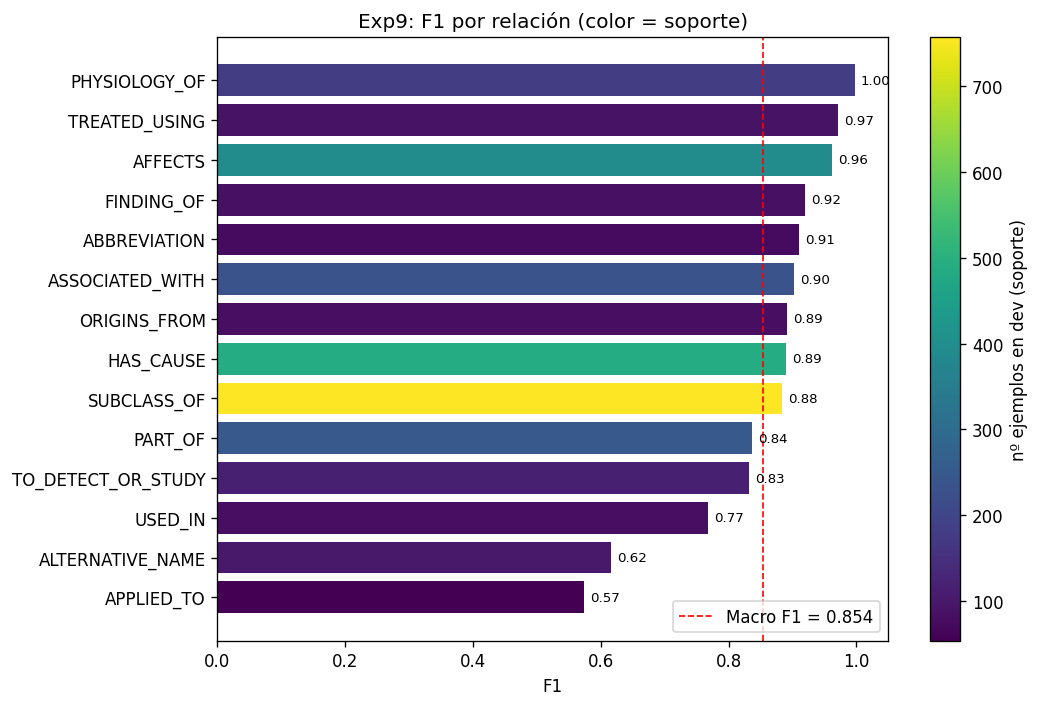

Peores 3: ['APPLIED_TO', 'ALTERNATIVE_NAME', 'USED_IN']


In [22]:
d = df.sort_values("f1")
norm = matplotlib.colors.Normalize(vmin=d["support"].min(), vmax=d["support"].max())
colors = plt.cm.viridis(norm(d["support"]))
fig, ax = plt.subplots(figsize=(9,6))
bars = ax.barh(d["relation"], d["f1"], color=colors)
ax.axvline(df["f1"].mean(), color="red", ls="--", lw=1, label=f"Macro F1 = {df['f1'].mean():.3f}")
for b,v in zip(bars, d["f1"]): ax.text(v+0.01, b.get_y()+b.get_height()/2, f"{v:.2f}", va="center", fontsize=8)
sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm); sm.set_array([])
cb = fig.colorbar(sm, ax=ax); cb.set_label("nº ejemplos en dev (soporte)")
ax.set_xlim(0,1.05); ax.set_xlabel("F1"); ax.set_title("Exp9: F1 por relación (color = soporte)")
ax.legend(loc="lower right"); plt.tight_layout()
plt.savefig(FIG_DIR/"f1_por_relacion.png", bbox_inches="tight"); plt.show()
print("Peores 3:", list(d.head(3)["relation"]))

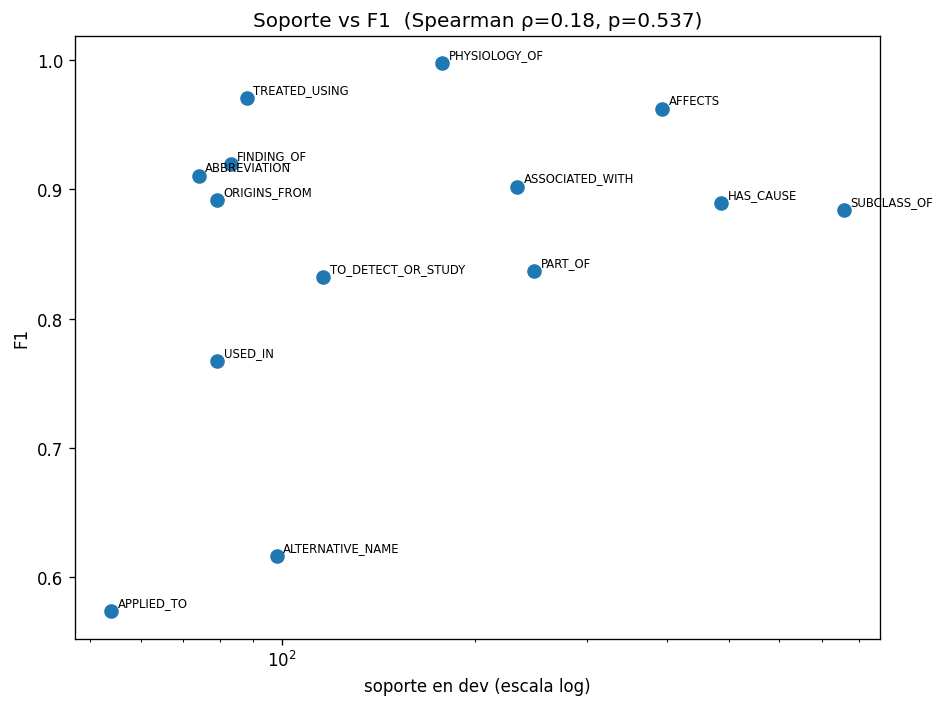

Correlación de rangos Spearman: ρ=0.180 (p=0.537)
ρ>0 y significativo => a más datos, mejor F1 (desbalanceo confirmado).


In [23]:
from scipy.stats import spearmanr
rho, pval = spearmanr(df["support"], df["f1"])
fig, ax = plt.subplots(figsize=(8,6))
ax.scatter(df["support"], df["f1"], s=60)
for _,r in df.iterrows():
    ax.annotate(r["relation"], (r["support"], r["f1"]), fontsize=7,
                xytext=(4,3), textcoords="offset points")
ax.set_xscale("log"); ax.set_xlabel("soporte en dev (escala log)"); ax.set_ylabel("F1")
ax.set_title(f"Soporte vs F1  (Spearman ρ={rho:.2f}, p={pval:.3f})")
plt.tight_layout(); plt.savefig(FIG_DIR/"soporte_vs_f1.png", bbox_inches="tight"); plt.show()
print(f"Correlación de rangos Spearman: ρ={rho:.3f} (p={pval:.3f})")
print("ρ>0 y significativo => a más datos, mejor F1 (desbalanceo confirmado).")

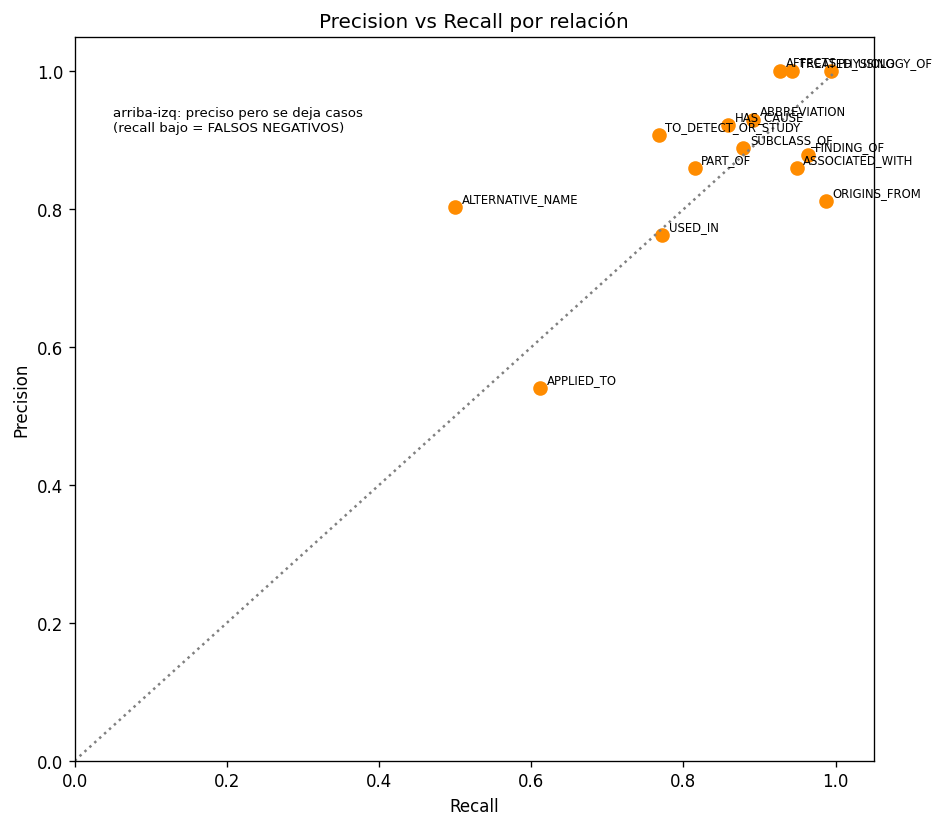

Clases con recall < 0.7 (candidatas a falso negativo):
        relation  precision   recall       f1  support
ALTERNATIVE_NAME   0.803279 0.500000 0.616352       98
      APPLIED_TO   0.540984 0.611111 0.573913       54


In [24]:
fig, ax = plt.subplots(figsize=(8,7))
ax.scatter(df["recall"], df["precision"], s=60, c="darkorange")
for _,r in df.iterrows():
    ax.annotate(r["relation"], (r["recall"], r["precision"]), fontsize=7,
                xytext=(4,3), textcoords="offset points")
ax.plot([0,1],[0,1], ls=":", c="gray")
ax.set_xlim(0,1.05); ax.set_ylim(0,1.05)
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Precision vs Recall por relación")
ax.text(0.05,0.95,"arriba-izq: preciso pero se deja casos\n(recall bajo = FALSOS NEGATIVOS)",
        fontsize=8, va="top")
plt.tight_layout(); plt.savefig(FIG_DIR/"precision_vs_recall.png", bbox_inches="tight"); plt.show()
print("Clases con recall < 0.7 (candidatas a falso negativo):")
print(df[df["recall"]<0.7][["relation","precision","recall","f1","support"]].to_string(index=False))

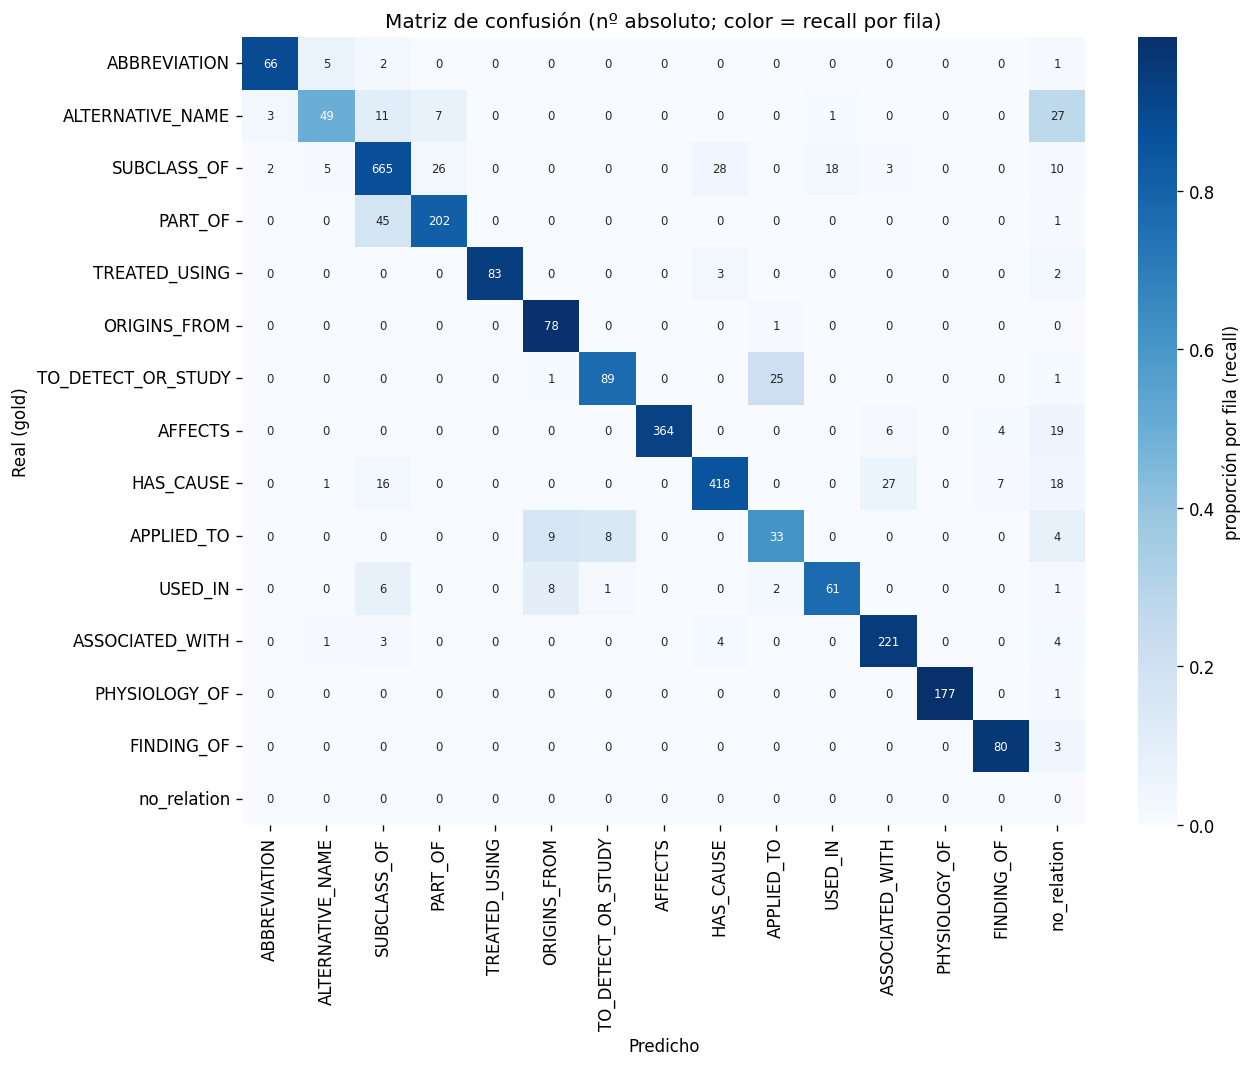

In [25]:
ALL = REL_ORDER + ["no_relation"]
idx = {r:i for i,r in enumerate(ALL)}
M = np.zeros((len(ALL), len(ALL)), dtype=int)
for g,p in zip(gold,pred): M[idx[g], idx[p]] += 1
Mn = M / M.sum(axis=1, keepdims=True).clip(min=1)   # normaliza por fila

fig, ax = plt.subplots(figsize=(11,9))
if HAS_SNS:
    sns.heatmap(Mn, annot=M, fmt="d", cmap="Blues", xticklabels=ALL, yticklabels=ALL,
                cbar_kws={"label":"proporción por fila (recall)"}, ax=ax, annot_kws={"size":7})
else:
    im=ax.imshow(Mn, cmap="Blues"); fig.colorbar(im, ax=ax)
    ax.set_xticks(range(len(ALL))); ax.set_xticklabels(ALL, rotation=90)
    ax.set_yticks(range(len(ALL))); ax.set_yticklabels(ALL)
ax.set_xlabel("Predicho"); ax.set_ylabel("Real (gold)")
ax.set_title("Matriz de confusión (nº absoluto; color = recall por fila)")
plt.xticks(rotation=90); plt.yticks(rotation=0)
plt.tight_layout(); plt.savefig(FIG_DIR/"matriz_confusion.png", bbox_inches="tight"); plt.show()

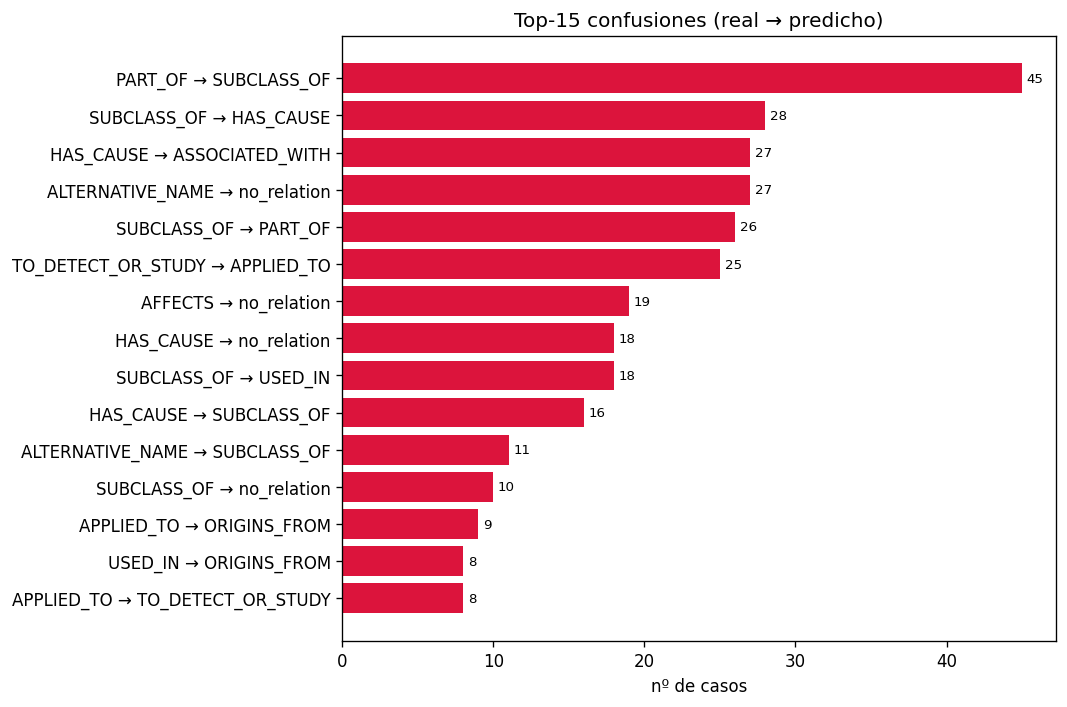

Top confusiones:
    45  PART_OF -> SUBCLASS_OF
    28  SUBCLASS_OF -> HAS_CAUSE
    27  HAS_CAUSE -> ASSOCIATED_WITH
    27  ALTERNATIVE_NAME -> no_relation
    26  SUBCLASS_OF -> PART_OF
    25  TO_DETECT_OR_STUDY -> APPLIED_TO
    19  AFFECTS -> no_relation
    18  HAS_CAUSE -> no_relation
    18  SUBCLASS_OF -> USED_IN
    16  HAS_CAUSE -> SUBCLASS_OF
    11  ALTERNATIVE_NAME -> SUBCLASS_OF
    10  SUBCLASS_OF -> no_relation
     9  APPLIED_TO -> ORIGINS_FROM
     8  USED_IN -> ORIGINS_FROM
     8  APPLIED_TO -> TO_DETECT_OR_STUDY


In [26]:
conf = Counter((g,p) for g,p in zip(gold,pred) if g!=p)
top = conf.most_common(15)
labels = [f"{g} → {p}" for (g,p),_ in top]
vals = [c for _,c in top]
fig, ax = plt.subplots(figsize=(9,6))
ax.barh(labels[::-1], vals[::-1], color="crimson")
for i,v in enumerate(vals[::-1]): ax.text(v+0.3, i, str(v), va="center", fontsize=8)
ax.set_xlabel("nº de casos"); ax.set_title("Top-15 confusiones (real → predicho)")
plt.tight_layout(); plt.savefig(FIG_DIR/"top_confusiones.png", bbox_inches="tight"); plt.show()
print("Top confusiones:")
for (g,p),c in top: print(f"  {c:>4}  {g} -> {p}")

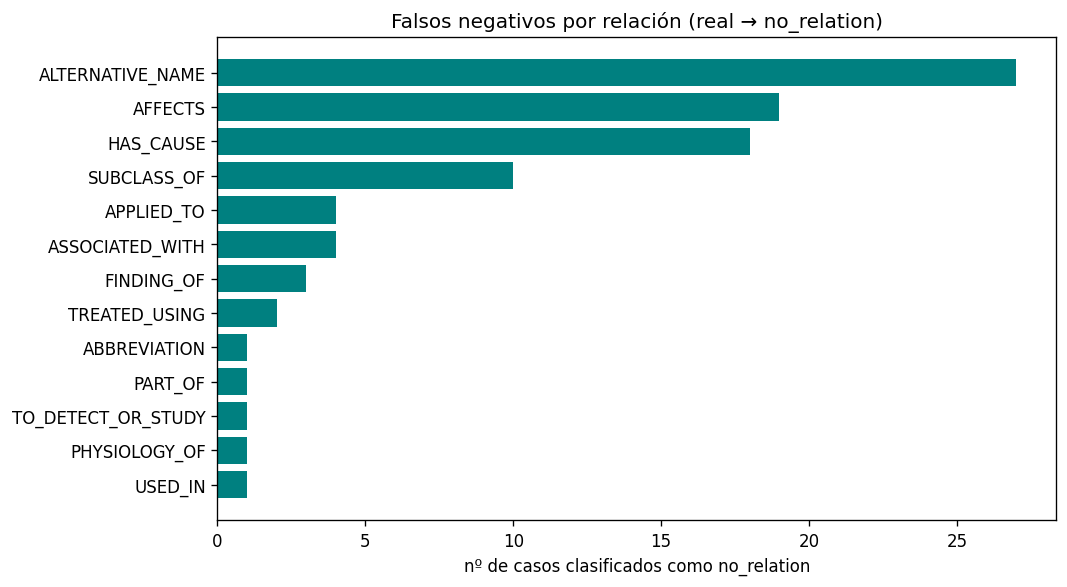

Falsos negativos totales: 92  (24.1% de TODOS los errores)


In [27]:
fn = Counter(g for g,p in zip(gold,pred) if p=="no_relation" and g!="no_relation")
if fn:
    items = fn.most_common()
    fig, ax = plt.subplots(figsize=(9,5))
    ax.barh([k for k,_ in items][::-1], [v for _,v in items][::-1], color="teal")
    ax.set_xlabel("nº de casos clasificados como no_relation")
    ax.set_title("Falsos negativos por relación (real → no_relation)")
    plt.tight_layout(); plt.savefig(FIG_DIR/"falsos_negativos.png", bbox_inches="tight"); plt.show()
    total_fn = sum(fn.values()); total_err = sum(1 for g,p in zip(gold,pred) if g!=p)
    print(f"Falsos negativos totales: {total_fn}  ({100*total_fn/total_err:.1f}% de TODOS los errores)")
else:
    print("No hay falsos negativos hacia no_relation.")

In [28]:
ps = sum(1 for g,p in zip(gold,pred) if g=="PART_OF" and p=="SUBCLASS_OF")
sp = sum(1 for g,p in zip(gold,pred) if g=="SUBCLASS_OF" and p=="PART_OF")
print(f"PART_OF  -> SUBCLASS_OF : {ps} casos")
print(f"SUBCLASS_OF -> PART_OF  : {sp} casos")
r_po = df[df.relation=='PART_OF'].iloc[0]; r_so = df[df.relation=='SUBCLASS_OF'].iloc[0]
print(f"\nPART_OF     F1={r_po.f1:.3f} (P={r_po.precision:.3f} R={r_po.recall:.3f}, sup={int(r_po.support)})")
print(f"SUBCLASS_OF F1={r_so.f1:.3f} (P={r_so.precision:.3f} R={r_so.recall:.3f}, sup={int(r_so.support)})")

PART_OF  -> SUBCLASS_OF : 45 casos
SUBCLASS_OF -> PART_OF  : 26 casos

PART_OF     F1=0.836 (P=0.860 R=0.815, sup=248)
SUBCLASS_OF F1=0.884 (P=0.889 R=0.878, sup=757)


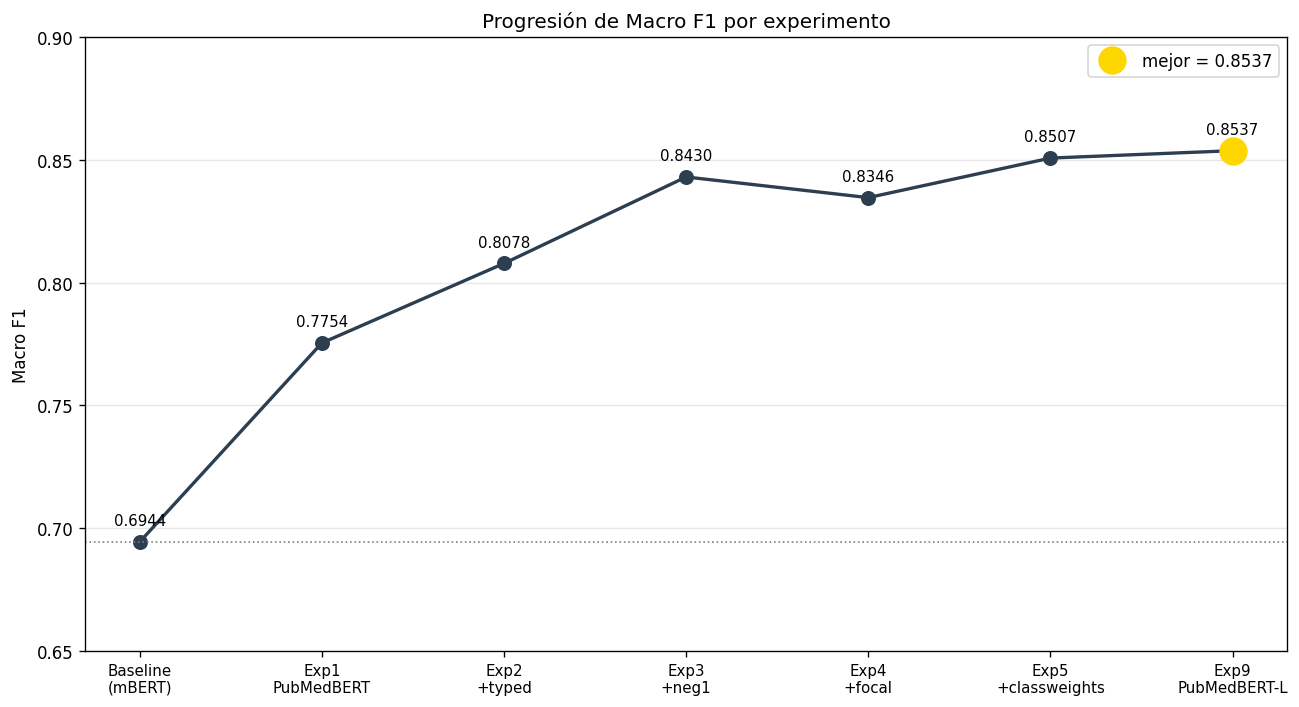

In [29]:
hist = [("Baseline\n(mBERT)",0.6944),("Exp1\nPubMedBERT",0.7754),("Exp2\n+typed",0.8078),
        ("Exp3\n+neg1",0.8430),("Exp4\n+focal",0.8346),("Exp5\n+classweights",0.8507),
        ("Exp9\nPubMedBERT-L",macro)]
names=[h[0] for h in hist]; vals=[h[1] for h in hist]
fig, ax = plt.subplots(figsize=(11,6))
ax.plot(range(len(vals)), vals, "-o", color="#2c3e50", lw=2, ms=8)
best = int(np.argmax(vals))
ax.plot(best, vals[best], "o", color="gold", ms=16, zorder=3, label=f"mejor = {vals[best]:.4f}")
for i,v in enumerate(vals): ax.annotate(f"{v:.4f}", (i,v), textcoords="offset points",
                                        xytext=(0,10), ha="center", fontsize=9)
ax.set_xticks(range(len(names))); ax.set_xticklabels(names, fontsize=9)
ax.set_ylabel("Macro F1"); ax.set_ylim(0.65,0.90)
ax.axhline(0.6944, color="gray", ls=":", lw=1)
ax.set_title("Progresión de Macro F1 por experimento"); ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.savefig(FIG_DIR/"progresion_experimentos.png", bbox_inches="tight"); plt.show()

In [3]:
import json, torch
from pathlib import Path
from collections import Counter
import opennre

# --- 1. localizar los ficheros en /kaggle/input (busca en todos los datasets adjuntos) ---
INPUT = Path("/kaggle/input")
def find(nombre):
    hits = list(INPUT.rglob(nombre))
    assert hits, f"No encuentro {nombre} en /kaggle/input. ¿Adjuntaste el dataset 9_output?"
    return hits[0]

TYPED_DEV   = find("eng_dev_typed.txt")
TYPED_TRAIN = find("eng_train_typed_neg1.txt")
CKPT_PATH   = find("eng_pubmedbert_LARGE_typed_neg1_classweights.pth.tar")
REL2ID_PATH = find("rel2id.json")
print("dev   :", TYPED_DEV)
print("train :", TYPED_TRAIN)
print("ckpt  :", CKPT_PATH)
print("rel2id:", REL2ID_PATH)

# --- 2. config (debe coincidir con el Exp9) ---
MODEL_NAME = "microsoft/BiomedNLP-BiomedBERT-large-uncased-abstract"
EXPERIMENT_NAME = "pubmedbert_LARGE_typed_neg1_classweights"
MAX_LENGTH = 256
rel2id = json.load(open(REL2ID_PATH)); id2rel = {v:k for k,v in rel2id.items()}

OUTPUT_DIR = Path("/kaggle/working/outputs"); OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# --- 3. arreglo del modelo large (igual que en el Exp9) ---
def fix_encoder_for_large(encoder):
    h = encoder.bert.config.hidden_size; expected = h*2
    if getattr(encoder, "hidden_size", None) != expected:
        encoder.hidden_size = expected
        encoder.linear = torch.nn.Linear(expected, expected)
        print(f"[fix] encoder ajustado a hidden_size={h} -> linear {expected}x{expected}")
    return encoder

# --- 4. recargar el modelo desde el checkpoint ---
enc = opennre.encoder.BERTEntityEncoder(max_length=MAX_LENGTH, pretrain_path=MODEL_NAME)
enc = fix_encoder_for_large(enc)
m2 = opennre.model.SoftmaxNN(enc, len(rel2id), rel2id)
m2.load_state_dict(torch.load(str(CKPT_PATH), map_location="cpu")["state_dict"])
if torch.cuda.is_available(): m2 = m2.cuda()
m2.eval()

# --- 5. reconstruir dev, gold y pred ---
dev = [json.loads(l) for l in open(TYPED_DEV, encoding="utf-8") if l.strip()]
gold, pred = [], []
with torch.no_grad():
    for inst in dev:
        item = {"text": inst.get("text") or " ".join(inst.get("token", [])),
                "h": inst["h"], "t": inst["t"]}
        rel, _ = m2.infer(item)
        gold.append(inst["relation"]); pred.append(rel)

acc = sum(1 for g,p in zip(gold,pred) if g==p)/len(gold)
print(f"\nListo: {len(dev)} instancias | Accuracy {acc:.4f}")

2026-07-08 17:01:09,010 - root - INFO - Loading BERT pre-trained checkpoint.
2026-07-08 17:01:09,184 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/microsoft/BiomedNLP-BiomedBERT-large-uncased-abstract/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-07-08 17:01:09,185 - huggingface_hub.utils._http - WARNING - Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.


dev   : /kaggle/input/datasets/lucaespernjj/9-outputs/eng_dev_typed.txt
train : /kaggle/input/datasets/lucaespernjj/9-outputs/eng_train_typed_neg1.txt
ckpt  : /kaggle/input/datasets/lucaespernjj/9-outputs/eng_pubmedbert_LARGE_typed_neg1_classweights.pth.tar
rel2id: /kaggle/input/datasets/lucaespernjj/bionner-data/rel2id.json


2026-07-08 17:01:09,203 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/microsoft/BiomedNLP-BiomedBERT-large-uncased-abstract/f18ff5ec008285849e7c467b2618262b0def6238/config.json "HTTP/1.1 200 OK"
2026-07-08 17:01:09,223 - httpx - INFO - HTTP Request: GET https://huggingface.co/api/resolve-cache/models/microsoft/BiomedNLP-BiomedBERT-large-uncased-abstract/f18ff5ec008285849e7c467b2618262b0def6238/config.json "HTTP/1.1 200 OK"


config.json: 0.00B [00:00, ?B/s]

2026-07-08 17:01:09,290 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/microsoft/BiomedNLP-BiomedBERT-large-uncased-abstract/resolve/main/adapter_config.json "HTTP/1.1 404 Not Found"
2026-07-08 17:01:09,363 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/microsoft/BiomedNLP-BiomedBERT-large-uncased-abstract/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-07-08 17:01:09,382 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/microsoft/BiomedNLP-BiomedBERT-large-uncased-abstract/f18ff5ec008285849e7c467b2618262b0def6238/config.json "HTTP/1.1 200 OK"
2026-07-08 17:01:09,610 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/microsoft/BiomedNLP-BiomedBERT-large-uncased-abstract/resolve/main/model.safetensors "HTTP/1.1 404 Not Found"
2026-07-08 17:01:09,665 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/microsoft/BiomedNLP-BiomedBERT-large-uncased-abstract/resolve/main/model.safetensors.index.json "HTT

...

tokenizer_config.json:   0%|          | 0.00/27.0 [00:00<?, ?B/s]

2026-07-08 17:01:31,228 - httpx - INFO - HTTP Request: GET https://huggingface.co/api/models/microsoft/BiomedNLP-BiomedBERT-large-uncased-abstract/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
2026-07-08 17:01:31,283 - httpx - INFO - HTTP Request: GET https://huggingface.co/api/models/microsoft/BiomedNLP-BiomedBERT-large-uncased-abstract/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"
2026-07-08 17:01:31,334 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/microsoft/BiomedNLP-BiomedBERT-large-uncased-abstract/resolve/main/vocab.txt "HTTP/1.1 307 Temporary Redirect"
2026-07-08 17:01:31,353 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/microsoft/BiomedNLP-BiomedBERT-large-uncased-abstract/f18ff5ec008285849e7c467b2618262b0def6238/vocab.txt "HTTP/1.1 200 OK"
2026-07-08 17:01:31,375 - httpx - INFO - HTTP Request: GET https://huggingface.co/api/resolve-cache/models/microsoft/BiomedNLP-BiomedBE

vocab.txt: 0.00B [00:00, ?B/s]

2026-07-08 17:01:31,454 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/microsoft/BiomedNLP-BiomedBERT-large-uncased-abstract/resolve/main/tokenizer.json "HTTP/1.1 404 Not Found"
2026-07-08 17:01:31,512 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/microsoft/BiomedNLP-BiomedBERT-large-uncased-abstract/resolve/main/added_tokens.json "HTTP/1.1 404 Not Found"
2026-07-08 17:01:31,565 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/microsoft/BiomedNLP-BiomedBERT-large-uncased-abstract/resolve/main/special_tokens_map.json "HTTP/1.1 404 Not Found"
2026-07-08 17:01:31,616 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/microsoft/BiomedNLP-BiomedBERT-large-uncased-abstract/resolve/main/chat_template.jinja "HTTP/1.1 404 Not Found"


[fix] encoder ajustado a hidden_size=1024 -> linear 2048x2048

Listo: 2967 instancias | Accuracy 0.8716


In [7]:
import re, pandas as pd
from collections import Counter

MARKER = re.compile(r"\[/?(?:HEAD|TAIL)-[A-Z_]+\]\s?")   # quita los typed markers del texto
def clean_text(t): return MARKER.sub("", t).strip()
def ent_name(inst, k):
    n = inst.get(k, {}).get("name")
    if n: return n
    a, b = inst[k]["pos"]; return inst["text"][a:b]   # fallback: recorta del texto por posición

# construir un registro por cada instancia de dev (gold, pred y las dos entidades)
records = []
for i, (inst, g, p) in enumerate(zip(dev, gold, pred)):
    records.append({
        "idx": i,
        "head": ent_name(inst, "h"),
        "tail": ent_name(inst, "t"),
        "head_type": inst.get("head_type", ""),
        "tail_type": inst.get("tail_type", ""),
        "gold": g,          # etiqueta correcta según el dataset
        "pred": p,          # lo que predijo el modelo
        "texto": clean_text(inst["text"]),
        "categoria_manual": "",   # <- rellenas tú: real_error / gold_dudoso / ambiguo
        "nota": "",               # <- comentario libre
    })
all_df = pd.DataFrame(records)
errors_df = all_df[all_df["gold"] != all_df["pred"]].copy()
print(f"Total instancias dev: {len(all_df)} | errores: {len(errors_df)}")

Total instancias dev: 2967 | errores: 381


In [10]:
AUDIT_DIR = OUTPUT_DIR / "auditoria"; AUDIT_DIR.mkdir(exist_ok=True, parents=True)

def export_bucket(df, nombre, mask):
    sub = df[mask].copy()
    path = AUDIT_DIR / f"{nombre}.csv"
    sub.to_csv(path, index=False, encoding="utf-8-sig")   # utf-8-sig => Excel lo abre bien
    print(f"  {len(sub):>3} casos -> {path.name}")
    return sub

print("Exportando bloques de auditoría:")
# 1) PART_OF <-> SUBCLASS_OF (los dos sentidos) — tu confusión #1
export_bucket(errors_df, "01_partof_vs_subclass",
    ((errors_df.gold=="PART_OF") & (errors_df.pred=="SUBCLASS_OF")) |
    ((errors_df.gold=="SUBCLASS_OF") & (errors_df.pred=="PART_OF")))

# 2) SUBCLASS_OF -> HAS_CAUSE (confusión rara, posible etiqueta dudosa)
export_bucket(errors_df, "02_subclass_to_hascause",
    (errors_df.gold=="SUBCLASS_OF") & (errors_df.pred=="HAS_CAUSE"))

# 3) ALTERNATIVE_NAME que el modelo NO detecta (falsos negativos)
export_bucket(errors_df, "03_altname_no_detectadas",
    (errors_df.gold=="ALTERNATIVE_NAME") & (errors_df.pred=="no_relation"))

# 4) TODOS los errores juntos, por si quieres explorar
errors_df.to_csv(AUDIT_DIR / "00_todos_los_errores.csv", index=False, encoding="utf-8-sig")
print(f"  {len(errors_df):>3} casos -> 00_todos_los_errores.csv")


Exportando bloques de auditoría:
   71 casos -> 01_partof_vs_subclass.csv
   28 casos -> 02_subclass_to_hascause.csv
   27 casos -> 03_altname_no_detectadas.csv
  381 casos -> 00_todos_los_errores.csv


In [9]:
mask = ((errors_df.gold=="PART_OF") & (errors_df.pred=="SUBCLASS_OF")) | \
       ((errors_df.gold=="SUBCLASS_OF") & (errors_df.pred=="PART_OF"))
vista = errors_df[mask][["head","tail","head_type","tail_type","gold","pred"]]
pd.set_option("display.max_rows", 100, "display.max_colwidth", 40)
vista

,head,tail,head_type,tail_type,gold,pred
71,thoracic spine,spine,ANATOMY,ANATOMY,PART_OF,SUBCLASS_OF
226,brain mitochondrial fraction,mitochondrial fraction,ANATOMY,ANATOMY,SUBCLASS_OF,PART_OF
491,sputum,pathological material,ANATOMY,ANATOMY,SUBCLASS_OF,PART_OF
498,peripheral blood cells,blood cells,ANATOMY,ANATOMY,PART_OF,SUBCLASS_OF
499,carotid artery,artery,ANATOMY,ANATOMY,SUBCLASS_OF,PART_OF
521,connective tissue,tissue,ANATOMY,ANATOMY,PART_OF,SUBCLASS_OF
523,lower leg,leg,ANATOMY,ANATOMY,PART_OF,SUBCLASS_OF
555,connective tissue,tissue,ANATOMY,ANATOMY,PART_OF,SUBCLASS_OF
581,lower extremities,upper and lower extremities,ANATOMY,ANATOMY,SUBCLASS_OF,PART_OF
679,right ICA,ICA,ANATOMY,ANATOMY,PART_OF,SUBCLASS_OF


## 10. PRUEBA DE ALTERNATIVE_NAME, se deja más de la mitad sin detectar.

ALTERNATIVE_NAME: 98 casos reales en dev
Fallos actuales (golds ALT no detectados): 49
   de esos, con P(ALT) > 0.1: 10 rescatables
   de esos, con P(ALT) > 0.2: 3 rescatables
   de esos, con P(ALT) > 0.3: 1 rescatables
   de esos, con P(ALT) > 0.4: 1 rescatables


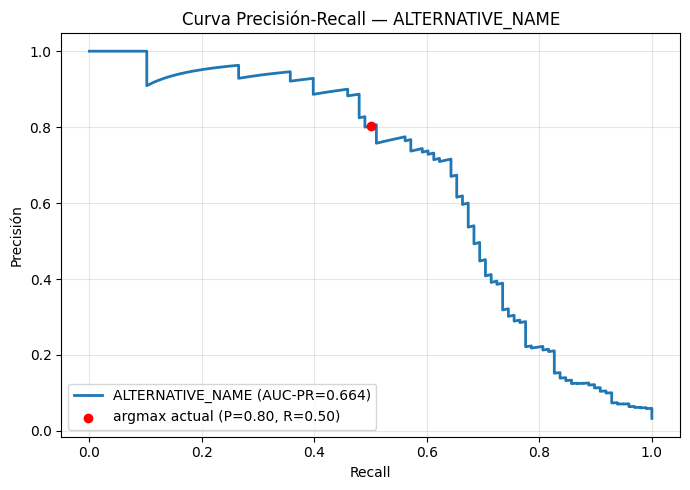


  tau  precision  recall    f1  TP  FP
0.10      0.738   0.602 0.663  59  21
0.15      0.740   0.582 0.651  57  20
0.20      0.765   0.531 0.627  52  16
0.25      0.758   0.510 0.610  50  16
0.30      0.758   0.510 0.610  50  16
0.40      0.806   0.510 0.625  50  12
0.50      0.803   0.500 0.616  49  12

Mejor F1 de ALTERNATIVE_NAME: 0.663 en tau=0.1 (P=0.738, R=0.602)  vs. F1 actual 0.616


In [6]:
# =====================================================================
#  ANÁLISIS DE UMBRAL PARA ALTERNATIVE_NAME  (post-hoc, sin reentrenar)
#  Pegar DESPUÉS de la celda 13. Reutiliza: m2, dev, rel2id, FIG_DIR, OUTPUT_DIR
# =====================================================================
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc

FIG_DIR = OUTPUT_DIR / "figs"; FIG_DIR.mkdir(exist_ok=True, parents=True)
TARGET = "ALTERNATIVE_NAME"
alt_id = rel2id[TARGET]
device = next(m2.parameters()).device

# ---------- 1) Reejecutar dev guardando la DISTRIBUCIÓN COMPLETA ----------
# m2.infer() solo devuelve el top-1 y tira el resto. Aquí replicamos su
# forward y nos quedamos con el softmax entero (15 probabilidades por par).
m2.eval()
probs = np.zeros((len(dev), len(rel2id)), dtype=np.float32)
gold_lbl = []
with torch.no_grad():
    for i, inst in enumerate(dev):
        item = {"text": inst.get("text") or " ".join(inst.get("token", [])),
                "h": inst["h"], "t": inst["t"]}
        tokens = m2.sentence_encoder.tokenize(item)      # tupla de tensores
        tokens = [t.to(device) for t in tokens]
        logits = m2.forward(*tokens)                     # [1, 15]
        probs[i] = torch.softmax(logits, -1).squeeze(0).cpu().numpy()
        gold_lbl.append(inst["relation"])

gold_lbl = np.array(gold_lbl)
p_alt = probs[:, alt_id]                 # P(ALTERNATIVE_NAME) de cada par
is_alt = (gold_lbl == TARGET)            # etiqueta real (one-vs-rest)
n_pos = int(is_alt.sum())
print(f"{TARGET}: {n_pos} casos reales en dev")

# ---------- 2) ¿Son rescatables los fallos actuales? ----------
argmax_pred = probs.argmax(1)
pred_alt_now = (argmax_pred == alt_id)
missed = is_alt & ~pred_alt_now          # golds ALT que el modelo NO detecta
print(f"Fallos actuales (golds ALT no detectados): {int(missed.sum())}")
for thr in [0.1, 0.2, 0.3, 0.4]:
    print(f"   de esos, con P(ALT) > {thr}: {int((missed & (p_alt > thr)).sum())} rescatables")

# ---------- 3) Curva Precisión-Recall (ALT como detector binario) ----------
prec, rec, _ = precision_recall_curve(is_alt.astype(int), p_alt)
ap = auc(rec, prec)
plt.figure(figsize=(7, 5))
plt.plot(rec, prec, lw=2, label=f"ALTERNATIVE_NAME (AUC-PR={ap:.3f})")
tp_now = int((is_alt & pred_alt_now).sum())
fp_now = int((~is_alt & pred_alt_now).sum())
P_now = tp_now / (tp_now + fp_now) if (tp_now + fp_now) else 0
R_now = tp_now / n_pos
plt.scatter([R_now], [P_now], color="red", zorder=5,
            label=f"argmax actual (P={P_now:.2f}, R={R_now:.2f})")
plt.xlabel("Recall"); plt.ylabel("Precisión")
plt.title("Curva Precisión-Recall — ALTERNATIVE_NAME")
plt.legend(loc="lower left"); plt.grid(alpha=.3); plt.tight_layout()
plt.savefig(FIG_DIR / "pr_alternative_name.png", bbox_inches="tight"); plt.show()

# ---------- 4) Tabla: qué pasa a cada umbral ----------
rows = []
for tau in [0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]:
    sel = p_alt > tau
    tp = int((sel & is_alt).sum()); fp = int((sel & ~is_alt).sum())
    P = tp / (tp + fp) if (tp + fp) else 0
    R = tp / n_pos
    F1 = 2 * P * R / (P + R) if (P + R) else 0
    rows.append({"tau": tau, "precision": round(P, 3), "recall": round(R, 3),
                 "f1": round(F1, 3), "TP": tp, "FP": fp})
tabla = pd.DataFrame(rows)
print("\n", tabla.to_string(index=False))
tabla.to_csv(OUTPUT_DIR / "umbral_altname.csv", index=False)
best = tabla.loc[tabla.f1.idxmax()]
print(f"\nMejor F1 de ALTERNATIVE_NAME: {best.f1} en tau={best.tau} "
      f"(P={best.precision}, R={best.recall})  vs. F1 actual 0.616")